# Table of contents

* **Introduction**
* **Objective**
* **Multi-Layer Perceptron Foundations**
* **Data dictionary**
* **Pipeline Overview**
* **Approach**
* **Setup Environments**
* **Data Loading**
* **Exploratory Data Analysis (EDA)**
* **Feature Engineering**
* **Model Training**
    * Model Architecture, Model Building, and Model Training (PyTorch)
* **Model Evaluation**
* **Conclusion**
* **References**

# Introduction

This tutorial presents a complete end-to-end implementation of a Multi-Layer Perceptron ($\text{MLP}$) using PyTorch for regression. The specific application involves predicting individual medical insurance charges (a continuous target variable) based on structured demographic and health-related features. The dataset includes inputs such as age, sex, $\text{BMI}$, number of children, smoking status, and region. This project serves as a practical demonstration of applying neural networks to standard tabular regression problems.

# Objective

The primary objectives established for this project are:
- To build and train a fully connected neural network ($\text{MLP}$) from scratch using PyTorch for the continuous prediction task.
- To effectively preprocess mixed-type data (numerical and categorical) for optimal deep learning input.
- To correctly standardize both feature data and the continuous target variable.To implement deep learning best practices, including using separate train and validation sets, monitoring loss, and utilizing $\text{early stopping}$ for regularization.
- To visualize the learned non-linear regression function in a reduced $2\text{D}$ space using $\text{PCA}$.To evaluate the final model's performance using standard, appropriate regression metrics.

# Multi-Layer Perceptron Foundations

The Multi-Layer Perceptron ($\text{MLP}$), a foundational architecture in deep learning, serves as a powerful tool for solving regression problems, where the goal is to predict a continuous numerical value. Its effectiveness stems from its ability to model highly non-linear relationships between input features and the target variable, a capability rooted in the Universal Approximation Theorem.

**The Architecture: Structure and Function**

An $\text{MLP}$ is a feedforward neural network comprising at least three layers: an input layer, one or more hidden layers, and an output layer.
- Linear Transformation: The process begins in each neuron with a linear combination of its inputs. The input features are multiplied by a corresponding weight matrix ($\mathbf{W}$) and added to a bias vector ($\mathbf{b}$). This operation, $\mathbf{y} = \mathbf{W}\mathbf{x} + \mathbf{b}$, constitutes the raw signal transmitted by the neuron.
- Non-Linearity (Activation): Following the linear transformation, an activation function is applied. This step is critical because without it, stacking multiple linear layers would only result in a single, simple linear function, limiting the model to simple linear regression. The most common choice for hidden layers is the Rectified Linear Unit ($\text{ReLU}$), which introduces the essential non-linearity, allowing the network to learn and represent complex, curved relationships inherent in the data.
- Output Layer: For regression tasks, the output layer must produce a single, unconstrained continuous value. Therefore, it typically consists of only one neuron and does not apply an activation function (like $\text{Sigmoid}$ or $\text{Softmax}$) after the final linear transformation. This ensures the prediction can exist anywhere on the real number line, matching the nature of the continuous target variable.

**The Training Process: Optimization and Learning**

The learning process in an $\text{MLP}$ is driven by minimizing prediction error across iterations.
- Loss Function: To quantify the error for a regression problem, the Mean Squared Error ($\text{MSE}$) is the standard choice. $\text{MSE}$ calculates the average of the squared differences between the predicted value and the true value, which is expressed as $\text{MSE} = \frac{1}{N} \sum_{i=1}^{N} (y_i - \hat{y}_i)^2$. The squaring of the error quadratically penalizes larger prediction mistakes, forcing the model to prioritize getting close to the target value for all data points.
- Gradient Descent and Backpropagation: Training relies on an optimization algorithm, often $\text{Adam}$, which is a variant of Stochastic Gradient Descent ($\text{SGD}$). The algorithm iteratively adjusts the network's weights and biases to reduce the loss. This adjustment is achieved via backpropagation, where the loss is calculated, and the gradient (the slope of the loss function with respect to each weight) is computed and propagated backward through the network. The gradients indicate the direction and magnitude required to update the weights to decrease the loss.
- Learning Rate: The learning rate is a hyperparameter that controls the step size of the weight updates during gradient descent. If the learning rate is too large, the optimizer may overshoot the minimum of the loss function. If it is too small, convergence will be slow.

**Generalization and Preventing Overfitting**

A successful regression model must generalize well, meaning it performs accurately on unseen data. Two key concepts ensure this:
- Data Preprocessing: Scaling continuous features, typically using Standard Scaling, is necessary to ensure that features with larger numerical ranges do not dominate the gradient calculations. For the target variable, scaling is also performed to stabilize the loss function and facilitate faster convergence.
- Validation and Early Stopping: To prevent overfitting (where the model memorizes the noise in the training data), a portion of the data is set aside as a validation set. During training, the loss on this validation set is monitored. Early stopping is a crucial regularization technique that terminates training when the validation loss fails to decrease for a set number of epochs. This prevents the model from continuing to learn training-specific noise and ensures that the final model state is the one that best generalizes to future, unseen data.

# Data dictionary

<style type="text/css">
.tg  {border-collapse:collapse;border-spacing:0;}
.tg td{border-color:black;border-style:solid;border-width:1px;font-family:Arial, sans-serif;font-size:14px;
  overflow:hidden;padding:10px 5px;word-break:normal;}
.tg th{border-color:black;border-style:solid;border-width:1px;font-family:Arial, sans-serif;font-size:14px;
  font-weight:normal;overflow:hidden;padding:10px 5px;word-break:normal;}
.tg .tg-za14{border-color:inherit;text-align:left;vertical-align:bottom}
.tg .tg-7zrl{text-align:left;vertical-align:bottom}
</style>
<table class="tg"><thead>
  <tr>
    <th class="tg-za14">Variable Name</th>
    <th class="tg-7zrl">Description</th>
    <th class="tg-7zrl">Data Type</th>
  </tr></thead>
<tbody>
  <tr>
    <td class="tg-7zrl">age</td>
    <td class="tg-7zrl">Edad del asegurado</td>
    <td class="tg-7zrl">Numerical</td>
  </tr>
  <tr>
    <td class="tg-7zrl">sex</td>
    <td class="tg-7zrl">Género</td>
    <td class="tg-7zrl">Categorical</td>
  </tr>
  <tr>
    <td class="tg-7zrl">bmi</td>
    <td class="tg-7zrl">Indice de masa corporal</td>
    <td class="tg-7zrl">Numerical</td>
  </tr>
  <tr>
    <td class="tg-7zrl">children</td>
    <td class="tg-7zrl">Número de hijos</td>
    <td class="tg-7zrl">Numerical</td>
  </tr>
  <tr>
    <td class="tg-7zrl">smoker</td>
    <td class="tg-7zrl">Indicador si fuma</td>
    <td class="tg-7zrl">Boolean</td>
  </tr>
  <tr>
    <td class="tg-7zrl">region</td>
    <td class="tg-7zrl">Región donde vive el asegurado</td>
    <td class="tg-7zrl">Categorical</td>
  </tr>
  <tr>
    <td class="tg-7zrl">charges</td>
    <td class="tg-7zrl">Prima del seguro</td>
    <td class="tg-7zrl">Numerical</td>
  </tr>
</tbody></table>

**[Dataset Link](https://www.kaggle.com/datasets/mirichoi0218/insurance)**

# Pipeline Overview

The complete workflow follows these distinct and structured stages:
- Data Loading and Exploratory Analysis
- Preprocessing Pipeline: Involves handling categorical variables (one-hot encoding), feature standardization (for both inputs and the target), and dimensionality reduction via $\text{PCA}$ (for visualization purposes).
- PyTorch Model Development: Covers $\text{Tensor}$ conversion, defining the custom $\text{MLP}$ architecture, and executing the training loop with validation.
- Model Interpretation and Visualization: Focuses on analyzing training history, plotting the learned regression surface, and assessing final performance.
- Final Evaluation on Hold-out Test Set

# Approach

**Preprocessing Pipeline Approach**

Given the dataset's nature, which includes both continuous and nominal features, a rigorous, sequential preprocessing strategy is implemented:
- Categorical Encoding: Binary categorical variables like smoker are converted using one-hot encoding (e.g., generating `smoker_no` and `smoker_yes` columns). Other categorical features like sex and region are excluded after preliminary analysis indicated their minimal correlation with the target variable, simplifying the input space.
- Feature and Target Scaling: Numerical features ($\text{age}$, $\text{bmi}$, $\text{children}$) are standardized using StandardScaler to achieve zero mean and unit variance.  This step is crucial for accelerating convergence and ensuring that no single feature dominates the weight updates during training. Critically, the continuous target variable (charges) is also standardized. Scaling the target is essential in regression neural networks for stable loss calculation and preventing activation saturation in the final layer.
- Dimensionality Reduction: Principal Component Analysis ($\text{PCA}$) is applied to the final, processed feature set. The feature set is reduced to just $2$ principal components. This step enables the visualization of the model's complex, learned regression surface in $2\text{D}$ or $3\text{D}$ plots.All feature transformations and scaling procedures are fitted exclusively on the training data to ensure that no information from the test set leaks into the preprocessing pipeline.

**Model Training Approach**

A foundational Multi-Layer Perceptron is custom-implemented using PyTorch's `nn.Module` system:
- Architecture: The network comprises an input layer (size $2$, matching the $\text{PCA}$ output), followed by a hidden layer of $64$ neurons using the $\text{ReLU}$ activation function, and a final output layer of size $1$. The output layer is linear, as required for continuous value prediction. The architecture flows from the input layer through the $\text{ReLU}$ layer to the final single continuous output.
- Optimization Components: The appropriate objective function for regression is the Mean Squared Error ($\text{MSELoss}$), which measures the average squared difference between predicted and actual values. The Adam optimizer is selected, set with a learning rate of $0.001$, balancing stability with convergence speed.
- Training Setup: The training data is split internally, allocating $20\%$ for a validation set to monitor generalization. Training is performed using full-batch gradient descent for a maximum of $100$ epochs. The key regularization technique is early stopping, implemented with a patience of $8$ epochs. This mechanism monitors the validation loss and automatically terminates training if performance does not improve within the patience window, ensuring the best performing model weights are automatically restored.

**Model Evaluation Approach**

Since the task is regression, the evaluation focuses on quantifying the magnitude and variance of the prediction error:
- Primary Metrics: Performance is quantified using the Mean Squared Error ($\text{MSE}$) and the Root Mean Squared Error ($\text{RMSE}$). These metrics measure the average magnitude of the prediction errors, with $\text{RMSE}$ being in the same unit as the original target variable. The $\text{R}$-squared (Coefficient of Determination) is also calculated, indicating the proportion of the target variable's variance explained by the model.
- Visual Diagnostics:The training and validation loss curves are plotted across epochs to diagnose convergence, stability, and potential overfitting.The most insightful visualization involves plotting the learned regression surface in the $2\text{D}$ $\text{PCA}$ space. This includes $2\text{D}$ contour plots showing predicted versus actual values and $3\text{D}$ plots of the regression manifold itself. All predictions are inverse-transformed back into the original charge units for real-world interpretability.

# Setup Environments

**Import Libraries**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pylab as pl
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D 
import missingno as msno 

from sklearn.utils import shuffle
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    mean_squared_error,
    r2_score,
    mean_absolute_error 
)
from sklearn.model_selection import (
    cross_val_score,
    GridSearchCV,
    train_test_split
)
from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder
)
from sklearn.decomposition import PCA 

import torch
import torch.nn as nn
import torch.optim as optim

%matplotlib inline

# Data Loading

The initial step involves loading the structured dataset containing medical insurance information.

In [ ]:
df = pd.read_csv('/kaggle/input/insurance/insurance.csv')
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


**Train and Test Split**

A foundational principle in machine learning dictates that the model's performance must be validated on data it has not encountered during training. To adhere to this, a train-test split is executed, partitioning the data into training and test sets ($80%$-$20%$ ratio). This procedure is essential to create a hold-out set for final, unbiased evaluation, thus preventing the critical issue of data leakage and ensuring the generalization capability of the subsequent Multi-Layer Perceptron ($\text{MLP}$) model is accurately assessed.

In [ ]:
train, test = train_test_split(df, test_size=0.2, random_state=42) 

print("train shape:", train.shape)
print("test shape:", test.shape)

train shape: (1070, 7)
test shape: (268, 7)


# Exploratory Data Analysis (EDA)

**Basic Statistics**

Exploratory Data Analysis provides an initial statistical and structural overview of the dataset. Descriptive statistics (mean, standard deviation, quartiles) for numerical features ($\text{age}$, $\text{bmi}$, $\text{children}$, $\text{charges}$) reveal their respective scales and value ranges. Data type inspection confirms the presence of three categorical features ($\text{sex}$, $\text{smoker}$, $\text{region}$) and four numerical features. A critical check confirms that the dataset exhibits zero missing values across all columns in both the training and test sets, indicating high data quality and eliminating the need for complex data imputation techniques.

In [5]:
train.head()

,age,sex,bmi,children,smoker,region,charges
560,46,female,19.95,2,no,northwest,9193.83850
1285,47,female,24.32,0,no,northeast,8534.67180
1142,52,female,24.86,0,no,southeast,27117.99378
969,39,female,34.32,5,no,southeast,8596.82780
486,54,female,21.47,3,no,northwest,12475.35130


In [6]:
train.describe()

,age,bmi,children,charges
count,1070.000000,1070.000000,1070.000000,1070.000000
mean,39.357009,30.560397,1.107477,13346.089736
std,14.073960,6.043386,1.215983,12019.510778
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.205000,0.000000,4897.667387
50%,39.500000,30.210000,1.000000,9575.442100
75%,51.000000,34.496250,2.000000,16746.657400
max,64.000000,53.130000,5.000000,62592.873090


In [7]:
train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1070 entries, 560 to 1126
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1070 non-null   int64  
 1   sex       1070 non-null   object 
 2   bmi       1070 non-null   float64
 3   children  1070 non-null   int64  
 4   smoker    1070 non-null   object 
 5   region    1070 non-null   object 
 6   charges   1070 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 66.9+ KB


**Missing Values Detection**

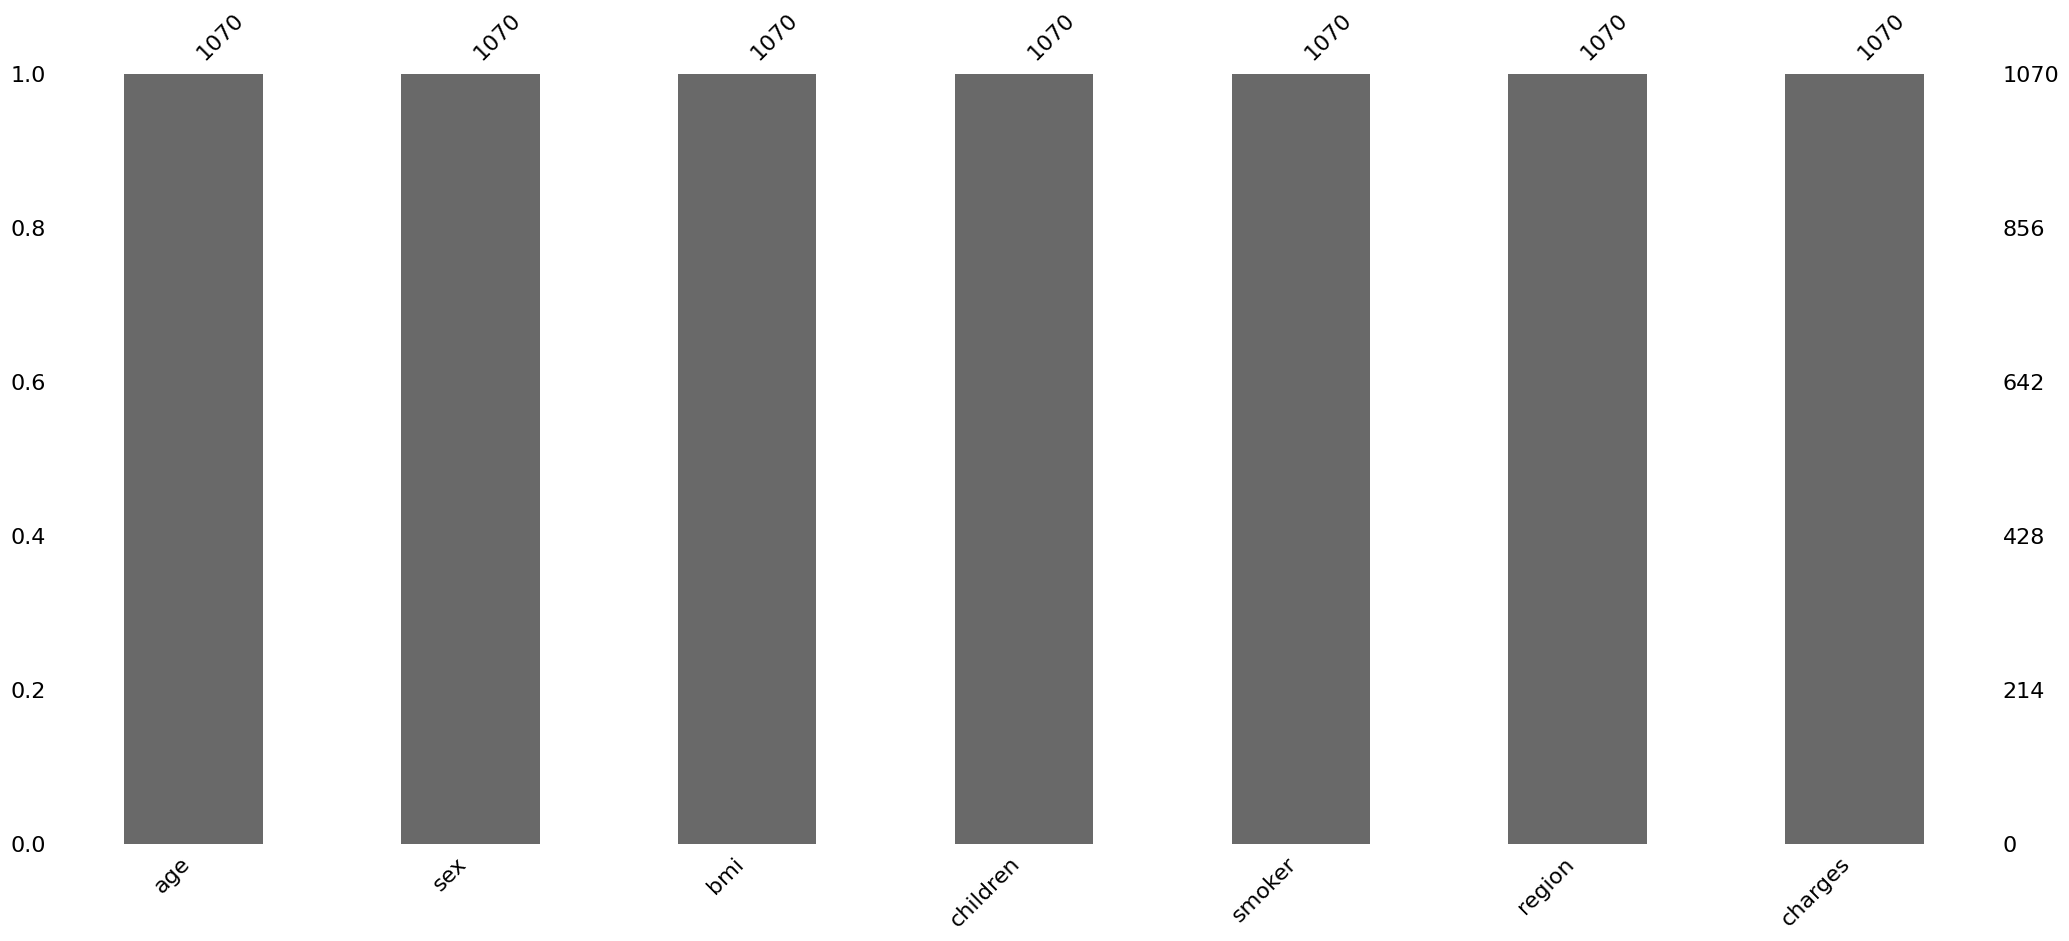

In [ ]:
msno.bar(train)
plt.show()

In [9]:
train.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [10]:
test.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [11]:
train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1070 entries, 560 to 1126
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1070 non-null   int64  
 1   sex       1070 non-null   object 
 2   bmi       1070 non-null   float64
 3   children  1070 non-null   int64  
 4   smoker    1070 non-null   object 
 5   region    1070 non-null   object 
 6   charges   1070 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 66.9+ KB


**Correlation Analysis**

To quantify the dependency between the input variables and the continuous target variable ($\text{charges}$), a correlation analysis is performed. The Spearman Rank Correlation coefficient is chosen over the standard Pearson coefficient. This choice is based on the robust nature of Spearman's, which measures the strength of monotonic (not necessarily linear) relationships between the ranks of the data, making it less sensitive to the distribution of the variables.

Prior to correlation calculation, categorical features must be numerically encoded. Binary categorical variables ($\text{smoker}$, $\text{sex}$) are mapped to $0$ and $1$. The nominal multi-class variable ($\text{region}$) is transformed using one-hot encoding, generating a set of binary indicator features (e.g., `region_northwest`). The resulting correlation matrix quantifies the strength of association between all processed features, which informs the selection and potential transformation of variables for the downstream $\text{MLP}$ model.

In [ ]:
# Preprocess Categorical Variables for numerical representation
# Binary categorical variables can be mapped to 0/1 with one-hot encoding.

df_processed = train.copy()
df_processed['sex'] = df_processed['sex'].map({'female': 0, 'male': 1})
df_processed['smoker'] = df_processed['smoker'].map({'no': 0, 'yes': 1})
df_processed = pd.get_dummies(df_processed, columns=['region'], drop_first=True)

# Calculate the Spearman Correlation Matrix
# Specify method='spearman'
spearman_correlation_matrix = df_processed.corr(method='spearman')

print("Spearman Correlation Matrix:")
spearman_correlation_matrix

Spearman Correlation Matrix:


,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest
age,1.000000,-0.007514,0.115408,0.074915,-0.052136,0.509846,0.016374,-0.019407,0.025868
sex,-0.007514,1.000000,0.013138,0.015945,0.070908,0.010859,0.017047,-0.008217,-0.013911
bmi,0.115408,0.013138,1.000000,0.001815,-0.000910,0.126142,-0.103393,0.227545,0.016553
children,0.074915,0.015945,0.001815,1.000000,0.023610,0.133833,0.044798,-0.023379,-0.009604
smoker,-0.052136,0.070908,-0.000910,0.023610,1.000000,0.661788,-0.030547,0.051450,-0.033688
charges,0.509846,0.010859,0.126142,0.133833,0.661788,1.000000,-0.009979,0.013010,-0.041507
region_northwest,0.016374,0.017047,-0.103393,0.044798,-0.030547,-0.009979,1.000000,-0.336290,-0.320954
region_southeast,-0.019407,-0.008217,0.227545,-0.023379,0.051450,0.013010,-0.336290,1.000000,-0.343194
region_southwest,0.025868,-0.013911,0.016553,-0.009604,-0.033688,-0.041507,-0.320954,-0.343194,1.000000


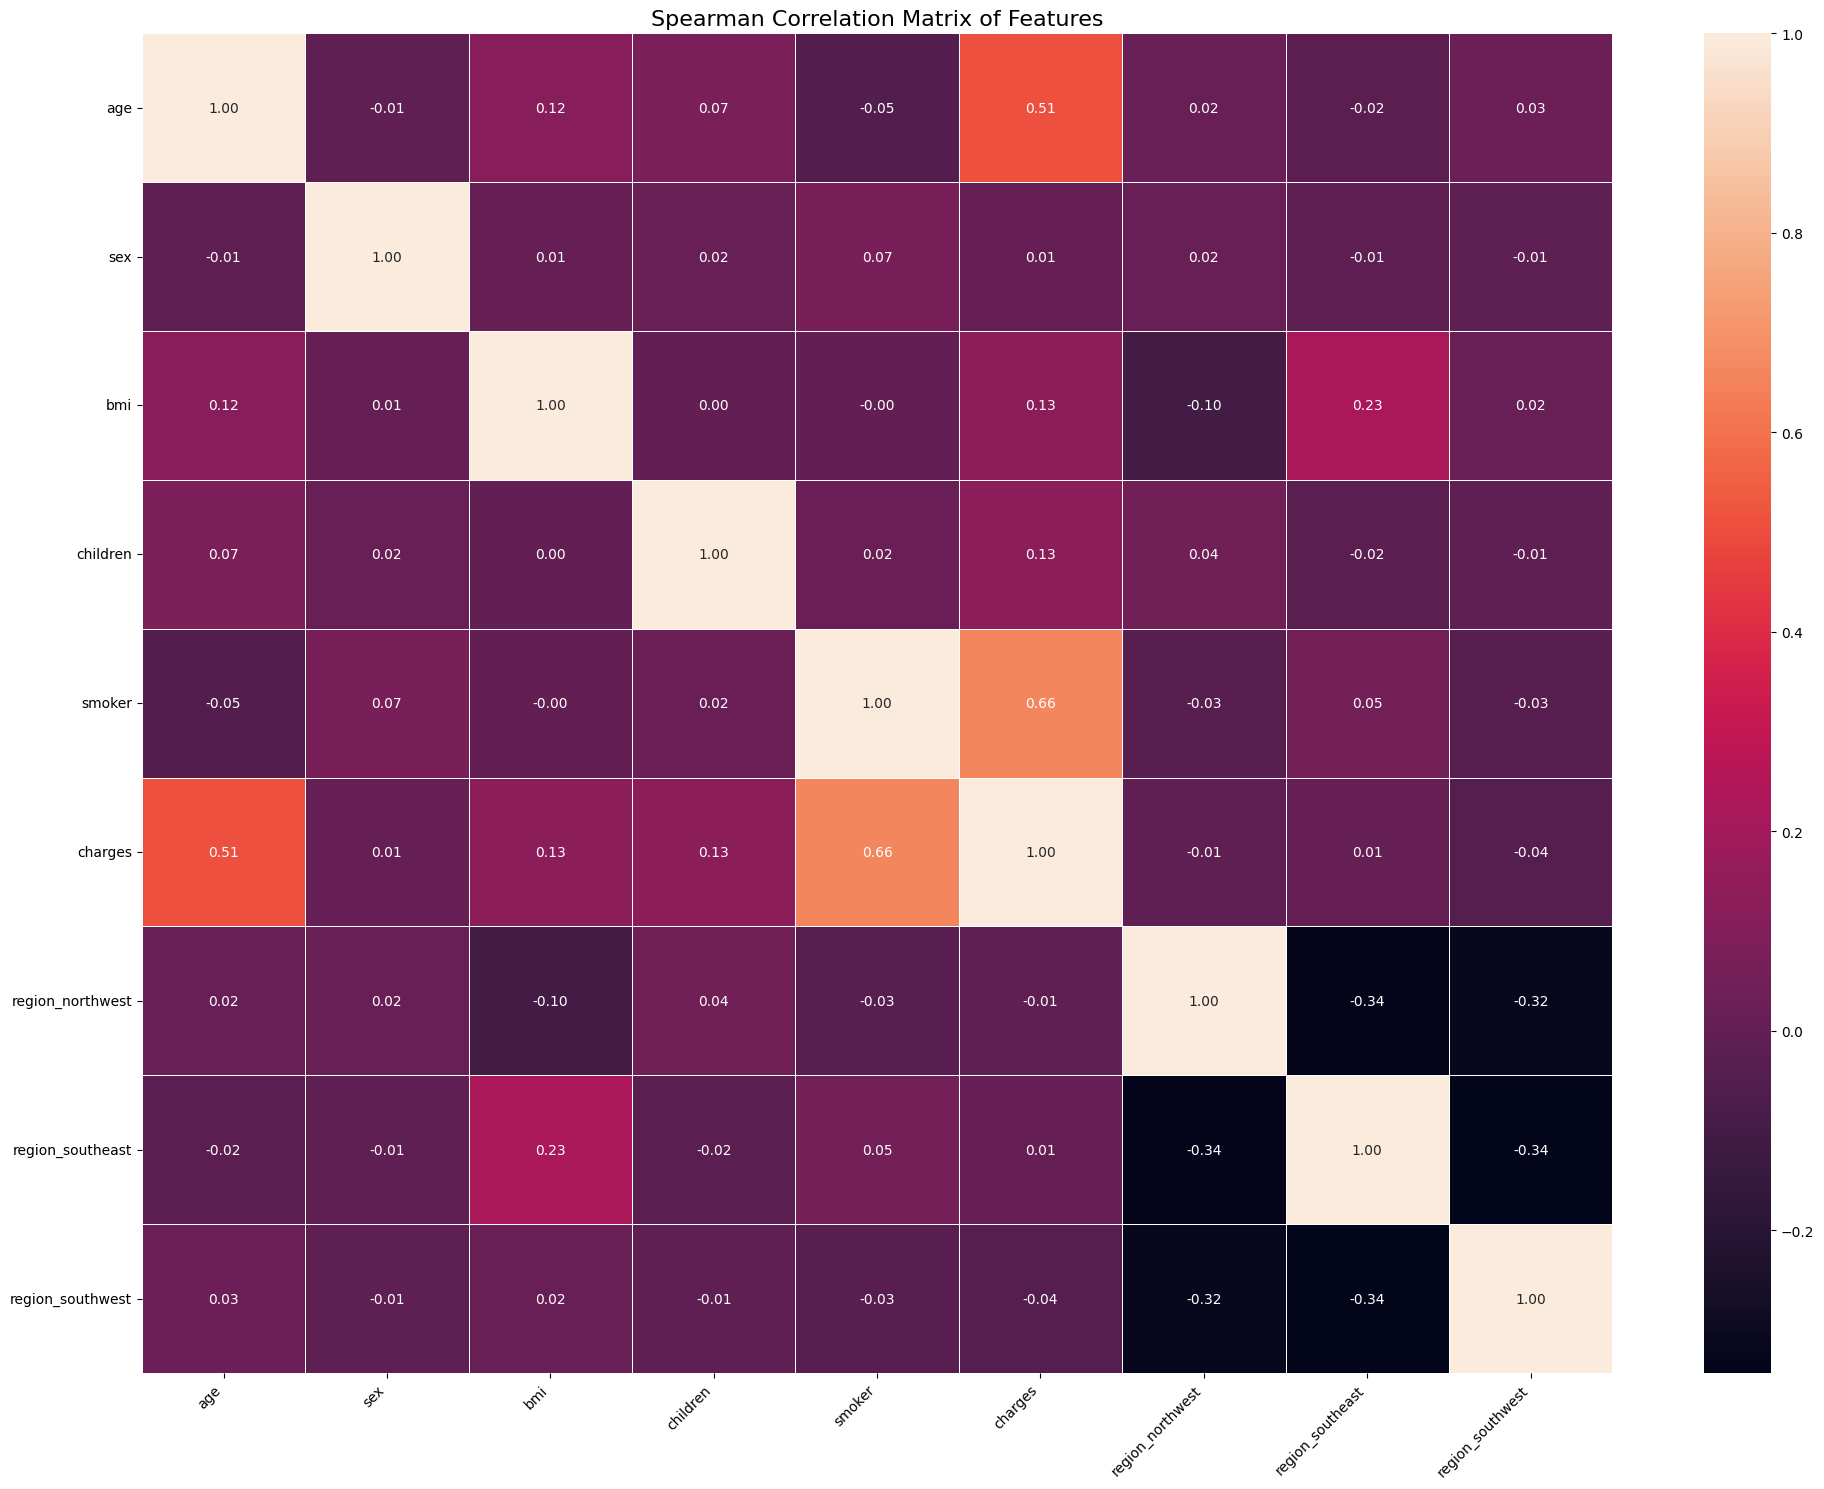

In [ ]:
# Visualize the Spearman Correlation Matrix using a Heatmap
plt.figure(figsize=(20, 15)) 
sns.heatmap(
    spearman_correlation_matrix,
    annot=True,    
    cmap='rocket',   
    fmt=".2f",     
    linewidths=.5    
)
plt.title('Spearman Correlation Matrix of Features', fontsize=16)
plt.xticks(rotation=45, ha='right') 
plt.yticks(rotation=0)
plt.tight_layout() 
plt.show()

**Correlation Heatmap**

The Spearman correlation heatmap confirms the predictive hierarchy of the features relative to $\text{charges}$. A very strong positive correlation is observed between $\text{smoker}$ status and $\text{charges}$ ($\text{r} \approx 0.66$), establishing this as the primary driver of insurance cost. A moderate positive correlation exists between $\text{age}$ and $\text{charges}$ ($\text{r} \approx 0.51$). Weaker positive associations are noted for $\text{bmi}$ and $\text{children}$ ($\text{r} \approx 0.13$). The remaining features ($\text{sex}$ and the regional indicators) exhibit near-zero correlation coefficients, suggesting minimal predictive power on a monotonic basis.

**Target Labels Distribution**


--- Distribution Plot of Charges ---


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


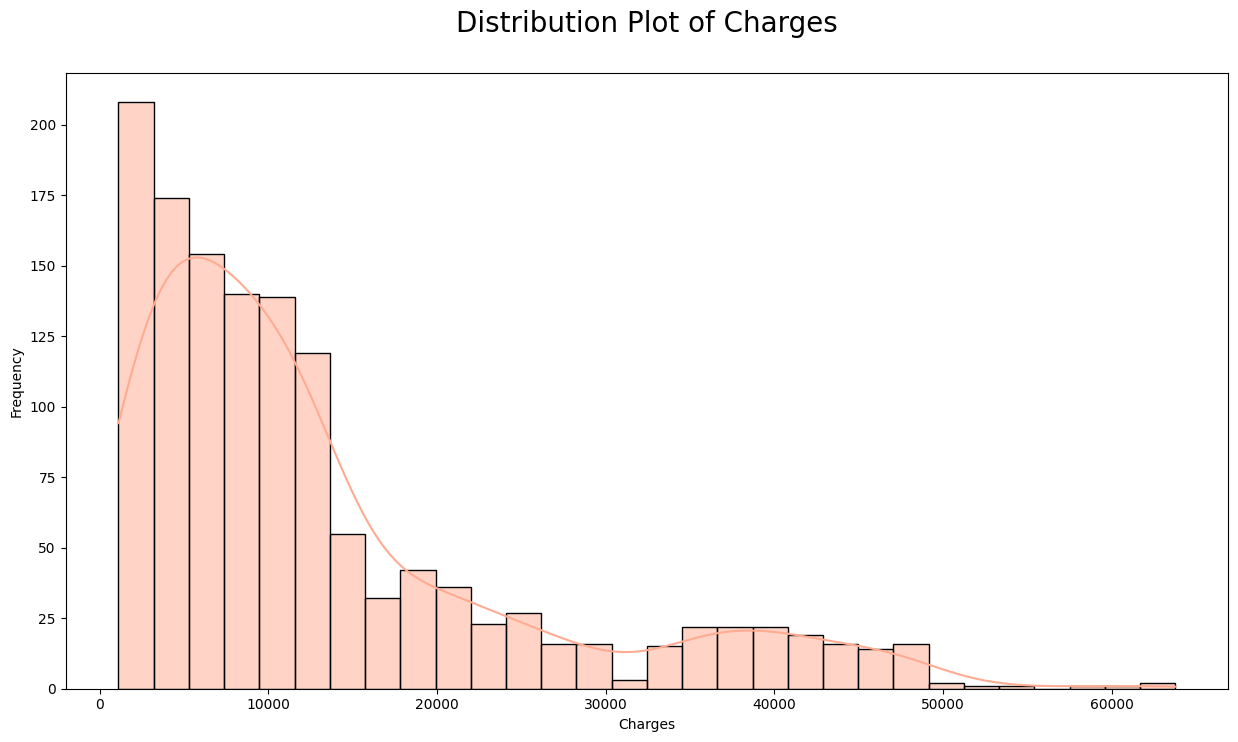

In [ ]:
print("\n--- Distribution Plot of Charges ---")
plt.figure(figsize = (15, 8))
sns.histplot(df['charges'], kde=True, color='#FFAB91') 
plt.title('Distribution Plot of Charges\n', fontsize = 20)
plt.xlabel('Charges')
plt.ylabel('Frequency')
plt.show()

**Distribution of Charges**

The distribution plot for the target variable, $\text{charges}$, clearly demonstrates a highly positive or right-skewed distribution.


--- Distribution Plot of Charges (Seaborn) ---


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-l

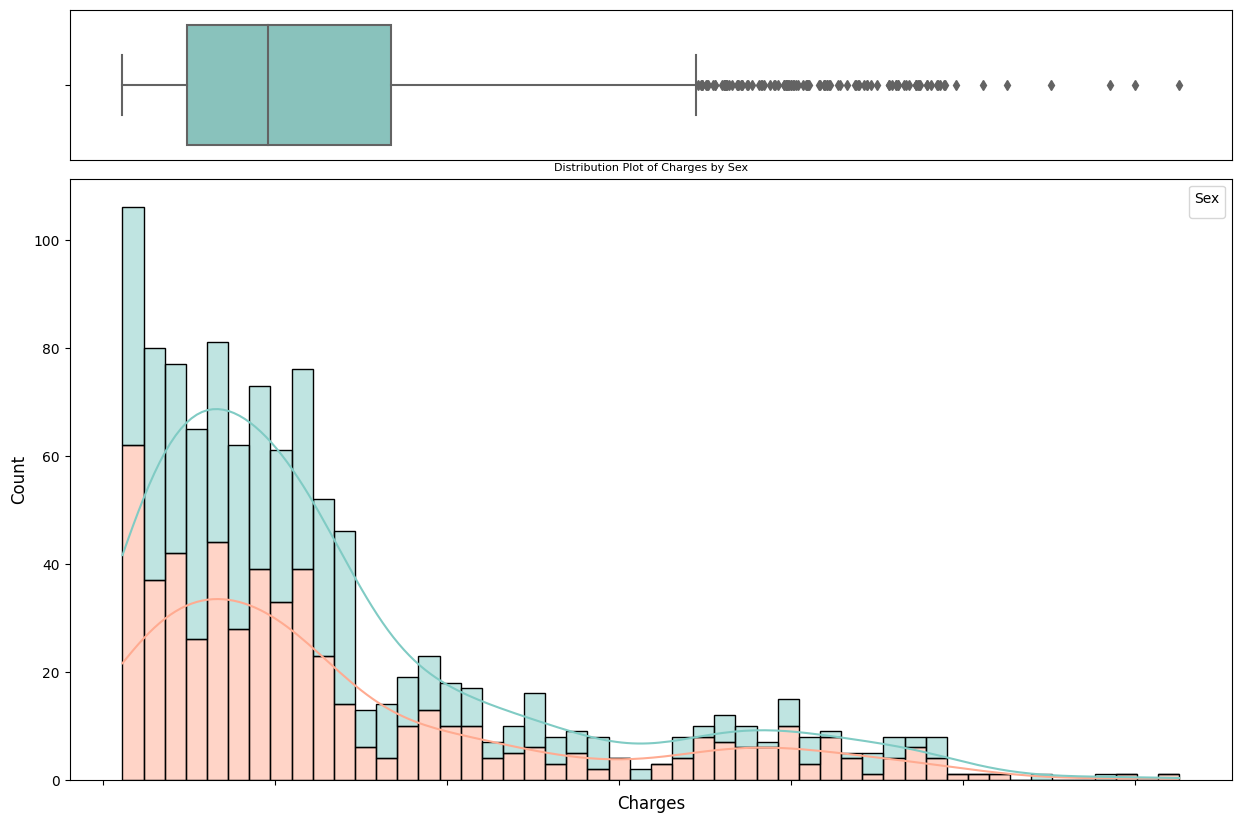

In [ ]:
print("\n--- Distribution Plot of Charges (Seaborn) ---")

fig = plt.figure(figsize=(15, 10))
gs = fig.add_gridspec(2, 1, height_ratios=[0.2, 0.8], hspace=0.05)

ax_box = fig.add_subplot(gs[0, 0])
ax_hist = fig.add_subplot(gs[1, 0], sharex=ax_box)

custom_palette = ["#80CBC4", "#FFAB91"]

sns.boxplot(data=train, x='charges', hue='sex', ax=ax_box, palette=custom_palette)
ax_box.set(xlabel='', xticklabels=[]) 
ax_box.tick_params(axis='x', bottom=False) 

sns.histplot(data=train, x='charges', hue='sex', multiple='stack', kde=True, bins=50, ax=ax_hist, palette=custom_palette)
ax_hist.set_title('Distribution Plot of Charges by Sex', fontsize=8)
ax_hist.set_xlabel('Charges', fontsize=12)
ax_hist.set_ylabel('Count', fontsize=12)
ax_hist.legend(title='Sex')

plt.tight_layout()
plt.show()

The majority of observations are concentrated at lower charge values, with a sparse, long tail extending toward extremely high costs. This suggests that the $\text{MSE}$ loss function, which heavily penalizes large errors, will be disproportionately influenced by the relatively few high-charge outliers. This structural skewness confirms the necessity of potentially applying a logarithmic transformation to the target variable before model training. Furthermore, the combined histogram and box plot separated by $\text{sex}$ reveal that both male and female groups share this highly skewed distribution, confirming that the $\text{sex}$ variable does not contribute a significant distributional difference in the charges.

# Feature Engineering

Feature engineering is a vital process that transforms raw data into a set of features that better represent the underlying problem to the predictive model, thereby improving model accuracy. The decision to drop the $\text{sex}$ and $\text{region}$ features is based on the earlier correlation analysis, which showed they had a near-zero or negligible correlation with the target variable ($\text{charges}$). By removing these non-predictive columns, the model's input space is simplified, reducing the risk of noise and potential overfitting while maintaining computational efficiency.

**Features Selection**

In [17]:
train = train.drop(columns=['sex', 'region'], errors='ignore')
test = test.drop(columns=['sex', 'region'], errors='ignore')
train.head()

,age,bmi,children,smoker,charges
560,46,19.95,2,no,9193.83850
1285,47,24.32,0,no,8534.67180
1142,52,24.86,0,no,27117.99378
969,39,34.32,5,no,8596.82780
486,54,21.47,3,no,12475.35130


**Categorical Encoding and Data Normalization**

**Categorical Encoding: One-Hot Encoding**

Deep learning models require numerical inputs; therefore, all categorical variables must be converted. One-Hot Encoding is the established method for nominal (unordered) categorical features like $\text{smoker}$. This process converts a single categorical column into multiple binary (0 or 1) columns, one for each unique category. For the $\text{smoker}$ column, this resulted in `smoker_no` and `smoker_yes`. This method prevents the model from incorrectly assuming any ordinal relationship between categories, a flaw that simple label encoding would introduce. Critically, the encoder must only be fitted on the training data to ensure the model does not implicitly learn distribution information or categories present only in the test set.

**Normalization : Standard Scaling**

Standard Scaling (`StandardScaler`) is applied to the numerical features ($\text{age}$, $\text{bmi}$, $\text{children}$) and, crucially, to the target variable ($\text{charges}$).  This technique transforms the data such that it has a mean of zero and a standard deviation of one.
- For Features: Scaling ensures that all inputs contribute equally to the distance calculations and gradient updates, preventing features with larger numerical ranges from dominating the optimization process of the $\text{MLP}$.
- For the Target Variable: Scaling the continuous target is highly recommended in neural networks. It keeps the loss function (Mean Squared Error) and subsequent gradients within a manageable range, which leads to faster and more stable convergence of the model during training.Similar to encoding, the scaler is fitted exclusively on the training set, and the derived scaling parameters (mean and standard deviation) are then applied to the test set, strictly adhering to the principle of preventing data leakage.

In [ ]:
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

encoder.fit(train[['smoker']])

smoker_encoded_train = encoder.transform(train[['smoker']])
smoker_df_train = pd.DataFrame(smoker_encoded_train, columns=encoder.get_feature_names_out(['smoker']), index=train.index)

smoker_encoded_test = encoder.transform(test[['smoker']])
smoker_df_test = pd.DataFrame(smoker_encoded_test, columns=encoder.get_feature_names_out(['smoker']), index=test.index)

train = train.drop('smoker', axis=1)
train = pd.concat([train, smoker_df_train], axis=1)

test = test.drop('smoker', axis=1)
test = pd.concat([test, smoker_df_test], axis=1)

numerical_cols = ['age', 'bmi', 'children'] 

scaler = StandardScaler()

scaler.fit(train[numerical_cols])

y_scaler = StandardScaler()
y_scaler.fit(train[['charges']])
train['charges'] = y_scaler.transform(train[['charges']])
test['charges'] = y_scaler.transform(test[['charges']])
train[numerical_cols] = scaler.transform(train[numerical_cols])
test[numerical_cols] = scaler.transform(test[numerical_cols])
train

,age,bmi,children,charges,smoker_no,smoker_yes
560,0.472227,-1.756525,0.734336,-0.345621,1.0,0.0
1285,0.543313,-1.033082,-0.911192,-0.400488,1.0,0.0
1142,0.898745,-0.943687,-0.911192,1.146332,1.0,0.0
969,-0.025379,0.622393,3.202629,-0.395314,1.0,0.0
486,1.040918,-1.504893,1.557100,-0.072478,1.0,0.0
...,...,...,...,...,...,...
1095,-1.518194,0.130717,2.379865,-0.731229,1.0,0.0
1130,-0.025379,-1.107579,3.202629,-0.396523,1.0,0.0
1294,1.325264,-0.891539,-0.911192,-0.117777,1.0,0.0
860,-0.167551,2.820864,0.734336,2.727461,0.0,1.0


**Features and Target Labels Split**

In [ ]:
x_train = train.drop('charges', axis=1) 
y_train = train['charges'] 
x_test = test.drop('charges', axis=1) 
y_test = test['charges'] 

print("X_train shape:", x_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", x_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (1070, 5)
y_train shape: (1070,)
X_test shape: (268, 5)
y_test shape: (268,)


**Dimensionality Reduction (PCA)**

**Dimensionality Reduction: Principal Component Analysis ($\text{PCA}$)**

Before feeding the processed data into the $\text{MLP}$, Principal Component Analysis ($\text{PCA}$) is applied. $\text{PCA}$ is a linear transformation technique that identifies the directions (principal components) in the high-dimensional feature space that account for the maximum variance. The objective here is to reduce the $5$ features to just $2$ principal components ($\text{PC1}$ and $\text{PC2}$).

In this tutorial context, the purpose of such an aggressive dimensionality reduction is twofold:
- Visualization: It compresses the complex, $5$-dimensional input space down to $2\text{D}$, allowing for a direct, visual plot of the data points, colored by the target variable.
- Model Interpretation: The reduced space makes it possible to visualize the $\text{MLP}$'s learned regression surface in $2\text{D}$ or $3\text{D}$, offering an intuitive way to assess how the model separates the data and predicts charges.

The $\text{PCA}$ transformation is fitted solely on the training set and then used to transform both the training and test features.

In [20]:
pca = PCA(n_components=2)
x_train = pca.fit_transform(x_train)
x_test = pca.transform(x_test)

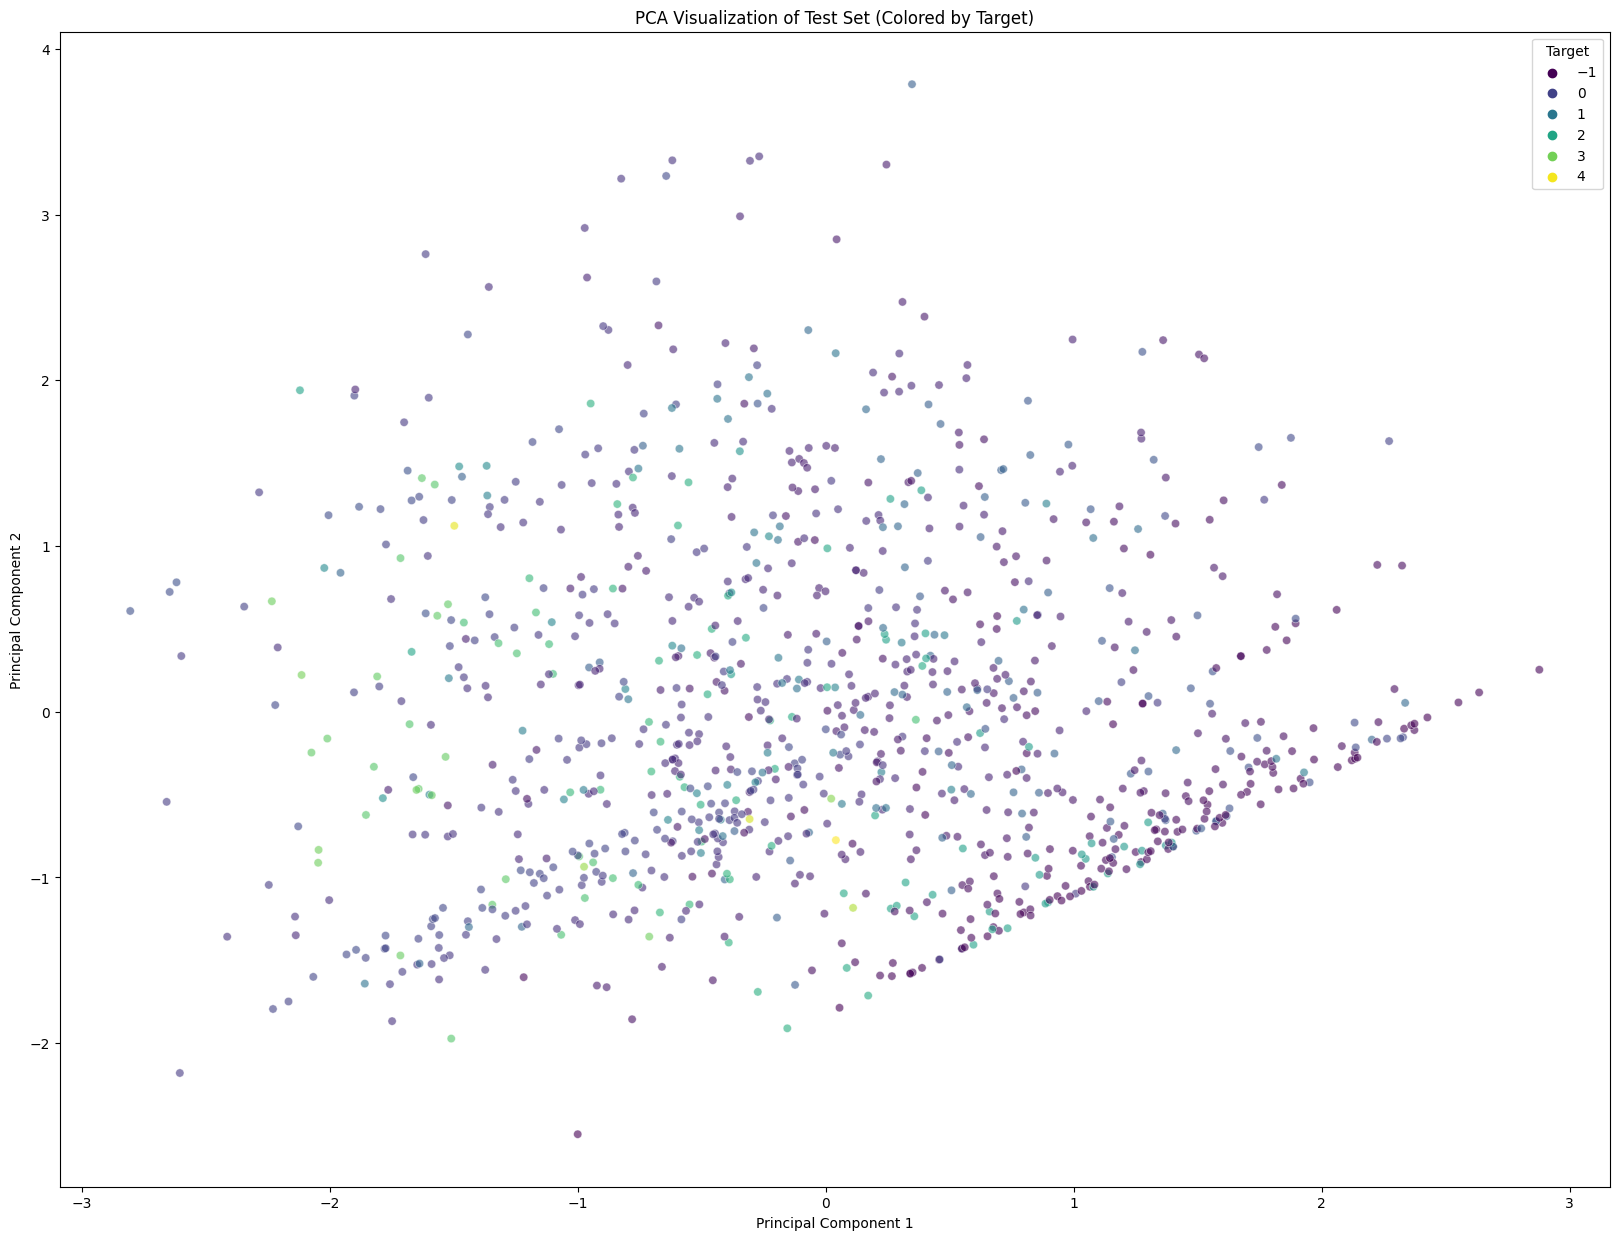

In [ ]:
plot_data = pd.DataFrame({
    'PC1': x_train[:, 0],
    'PC2': x_train[:, 1],
    'Target': y_train
})

plt.figure(figsize=(20, 15))
sns.scatterplot(
    data=plot_data,
    x="PC1",
    y="PC2",
    hue="Target",
    palette="viridis",
    alpha=0.6
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Visualization of Test Set (Colored by Target)")

plt.show()

**Interpretation of PCA Visualization**

The scatter plot displays the training data projected onto the $2$ principal components, with the color intensity representing the standardized insurance charges (`y_train`).
- Two Distinct Clusters: The visualization clearly reveals a fundamental clustering pattern in the data, which is highly driven by $\text{PC1}$. The majority of data points, characterized by lower charges (darker colors), are tightly grouped on the left side of the plot.
- High-Charge Separation ($\text{Smoker}$ Impact): A second, distinct cluster of points appears to be separated along the $\text{PC1}$ axis, moving significantly toward the right. This cluster corresponds almost entirely to the highest charge values (brighter colors). Given the earlier correlation analysis showed $\text{smoker}$ status was the strongest predictor ($\text{r} \approx 0.66$), $\text{PC1}$ is highly likely dominated by the variance introduced by the $\text{smoker}$ feature. This suggests that $\text{PC1}$ effectively separates non-smokers from smokers, where the smoker group corresponds to the higher charges.
- Predictive Manifold: The visualization confirms that the relationship between features and charges is not uniform. The $\text{MLP}$ model will need to learn a non-linear regression function that effectively isolates the high-charge cluster and models the highly non-linear increase in cost associated with the primary predictive component ($\text{PC1}$).

The success of the $\text{PCA}$ in capturing the target-relevant variance in just two dimensions validates its use for creating a visual, interpretable representation of the data before the $\text{MLP}$ training.

# Model Training

## Model Architecture, Model Building, and Model Training (PyTorch)

**Building an $\text{MLP}$ for Regression with PyTorch**

Constructing a Multi-Layer Perceptron ($\text{MLP}$) for regression in PyTorch involves defining the architecture, selecting the appropriate components for continuous output, and implementing a disciplined training loop. The foundation of any PyTorch model is the nn.Module class, which provides the necessary structure to define layers and manage parameters.

**$\text{MLP}$ Model Architecture**

The core of the $\text{MLP}$ is a sequence of linear transformations and non-linear activation functions.
- Input Layer and Hidden Layer (`nn.Linear`): This layer performs the primary operation of a neural network: a linear transformation on the input data, $\mathbf{y} = \mathbf{W}\mathbf{x} + \mathbf{b}$, where $\mathbf{W}$ is the weight matrix and $\mathbf{b}$ is the bias vector. In PyTorch, this is implemented using `nn.Linear(input_dim, hidden_dim)`. The `input_dim` is the number of features entering the layer (e.g., the 2 $\text{PCA}$ components), and the `hidden_dim` is the number of neurons in the hidden layer, which defines the model's capacity to learn complex features.
- Activation Function (`nn.ReLU`): The Rectified Linear Unit ($\text{ReLU}$), implemented as `nn.ReLU()`, introduces essential non-linearity between the linear layers. Without this, stacking multiple linear layers would simply result in another single linear function, limiting the model to simple linear regression. $\text{ReLU}$ allows the network to approximate complex, non-linear mappings.
- Output Layer: For a regression task, the output layer must produce a single, continuous value. This is achieved using another linear layer, `nn.Linear(hidden_dim, 1)`, where the output dimension is $1$. Crucially, no activation function (like $\text{Sigmoid}$ or $\text{Softmax}$) is applied after this final layer, allowing the output to span the full range of real numbers, which is necessary for predicting continuous target values.

**Model Training Components**

Once the architecture is defined, three main components are required for the training process: the loss function, the optimizer, and the training setup.
- Loss Function: For regression, the standard loss function is the Mean Squared Error ($\text{MSE}$), implemented as `nn.MSELoss()`. $\text{MSE}$ calculates the average squared difference between the model's predictions and the true target values. The squaring operation penalizes larger errors more heavily, driving the model to produce predictions as close as possible to the ground truth.
- Optimizer: The optimizer is the algorithm responsible for updating the model's weights based on the loss function's gradients (calculated via backpropagation). $\text{Adam}$ (`optim.Adam`) is a highly effective, adaptive optimization algorithm often chosen for its robust performance and fast convergence.
- Training Loop: The loop iteratively performs the forward pass, calculates the loss, computes the gradients (`loss.backward()`), and updates the weights (`optimizer.step()`). To prevent overfitting, a common technique called Early Stopping is used. This mechanism monitors the loss on a separate validation set and halts training when the validation loss stops improving for a specified number of epochs (`patience`), ensuring the best-generalized model state is saved.

**MLP Hyperparameters (PyTorch)**

Hyperparameters are configurations that are set before training begins and are not learned by the model itself. Effective machine learning often depends on tuning these values.

- Input Dimension (`input_dim`): This is the size of the feature vector for a single data point. Its value is determined by the preprocessed dataset and cannot be tuned; it must accurately reflect the number of features feeding into the first layer.
- Hidden Dimension (`hidden_dim`): This defines the number of neurons within each hidden layer. It is a key determinant of the model's capacity (complexity). A larger `hidden_dim` allows the model to capture more intricate patterns but increases computational cost and the risk of overfitting.
- Number of Layers: The depth of the network (how many hidden layers are stacked). Deeper networks can model more abstract relationships, but training becomes more challenging. A one-to-three-layer architecture is a good starting point for moderate problems.
- Learning Rate (`lr`): This controls the magnitude of the parameter update in each optimization step.  A small `lr` ensures stable convergence but can make training very slow. A large `lr` speeds up training but risks overshooting the optimal solution, potentially leading to divergence or unstable loss.
- Epochs: The total number of complete passes over the entire training dataset. This sets the maximum duration for training. The actual duration is often shorter, thanks to early stopping.
- Batch Size: The number of data samples processed in one forward/backward pass before the model's parameters are updated. A larger batch size provides a better estimate of the loss gradient but requires more memory.
- Patience (for Early Stopping): This is a critical regularization parameter. It specifies the number of epochs the training process will tolerate without seeing an improvement in the validation loss. Once this limit is reached, training is stopped, and the model state corresponding to the best historical validation performance is restored, preventing the model from overfit to the training data.

**Implementation**

**Tensor Conversion and Dataset Preparation**

The modeling process begins by converting the preprocessed numerical data (`x_train, y_train`) from $\text{NumPy}$ arrays into PyTorch $\text{Tensors}$. $\text{Tensors}$ are the fundamental data structure for all operations within PyTorch, facilitating efficient computation on $\text{CPUs}$ and $\text{GPUs}$. The standardized features and target variable are converted to `float32` data type to ensure numerical compatibility with the neural network architecture.

Following conversion, the training set is internally partitioned into a smaller training split and a validation split ($80%$-$20%$). The validation set is crucial for monitoring the model's performance on unseen data during the training loop. This allows for early detection of overfitting, where the model learns the noise in the training data rather than the underlying pattern.

**Model Architecture and Initialization**

The predictive model employed is a simple but effective Multi-Layer Perceptron ($\text{MLP}$), implemented as a custom class inheriting from PyTorch's `nn.Module`.  $\text{MLPs}$, also known as feedforward neural networks, consist of interconnected layers of neurons, with data flowing in one direction from input to output.The chosen architecture is composed of three main layers:
- Input Layer (`nn.Linear`): Takes $2$ features (the $\text{PC1}$ and $\text{PC2}$ components from $\text{PCA}$) and maps them to $64$ hidden units.
- Activation Function (`nn.ReLU`): The Rectified Linear Unit ($\text{ReLU}$) is applied after the first linear layer. $\text{ReLU}$ introduces the necessary non-linearity into the network, allowing the $\text{MLP}$ to learn complex, non-linear relationships in the data, which is essential for accurate regression of non-linear phenomena.
- Output Layer (`nn.Linear`): Maps the $64$ hidden units to a single output value ($1$), representing the predicted, standardized insurance charge. Since this is a regression task, the output layer does not use a final activation function (like $\text{softmax}$ or $\text{sigmoid}$), providing an unconstrained continuous output.

The total number of trainable parameters in this compact architecture is only $257$, making it lightweight and reducing the potential for severe overfitting on a small dataset.

**Training Loop and Regularization**

Model training involves iteratively adjusting the network's weights to minimize the prediction error.
- Loss Function: The objective function for this regression task is the Mean Squared Error (`MSELoss`). $\text{MSE}$ measures the average squared difference between the predicted and actual charges. Minimizing $\text{MSE}$ forces the model to prioritize reducing larger errors, ensuring the model's predictions are close to the actual continuous values.
- Optimizer: The Adam optimizer is utilized to drive the weight updates. Adam combines the benefits of adaptive learning rates (like `RMSprop`) and momentum, offering robust and efficient convergence. A standard learning rate of $0.001$ is selected.
- Training Loop: In each epoch, the model performs a forward pass to generate predictions, calculates the $\text{MSE}$ loss, executes a backward pass to compute gradients (using backpropagation), and finally, the optimizer steps to update the weights.
- Early Stopping: To combat overfitting, a vital regularization technique, early stopping, is implemented with a patience of $8$ epochs. Training is immediately halted if the validation loss fails to decrease over the defined patience period, and the model state corresponding to the best validation loss is restored. This practice ensures that the final model is the one that generalizes best to unseen data, not the one that achieves the lowest training error.

In [ ]:
# Convert NumPy arrays to PyTorch tensors
x_train_tensor = torch.tensor(x_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32) 

x_train_split, x_val_split, y_train_split, y_val_split = train_test_split(
    x_train_tensor, y_train_tensor, test_size=0.2, random_state=42
)

train_loss_history = []
val_loss_history = []

# Define the MLP Model using PyTorch's nn.Module (for Regression)
class MLPModel(nn.Module): 
    """
    A Multi-Layer Perceptron model implemented using PyTorch's nn.Module for REGRESSION.
    It consists of an input layer, a hidden layer with ReLU activation, and an output layer.
    """
    def __init__(self, input_dim, hidden_dim):
        """
        Initializes the MLPModel.

        Args:
            input_dim (int): The number of input features for the model.
            hidden_dim (int): The number of neurons in the hidden layer.
        """
        super(MLPModel, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim) # First fully connected layer
        self.relu = nn.ReLU() # ReLU activation function
        self.fc2 = nn.Linear(hidden_dim, 1) # Output layer for regression (single continuous output)

    def forward(self, x):
        """
        Defines the forward pass of the model.

        Args:
            x (torch.Tensor): The input tensor to the model.

        Returns:
            torch.Tensor: The output tensor after applying the linear transformation.
        """
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x

# Instantiate the model
input_dim = x_train.shape[1]
hidden_dim = 64 
model = MLPModel(input_dim, hidden_dim) 

print("\n--- Model Architecture ---")
print(model)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Number of trainable parameters: {total_params}")

# Loss Function and Optimizer (for Regression) 
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001) 

# Early Stopping
early_stopping_patience = 8
best_val_loss = float('inf')
patience_counter = 0
best_model_state = None


# Train the Model
epochs = 100
print("\n--- Training Model ---")
for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    outputs = model(x_train_split)
    loss = criterion(outputs, y_train_split)
    loss.backward()
    optimizer.step()

    # Validation
    model.eval()
    with torch.no_grad():
        val_outputs = model(x_val_split)
        val_loss = criterion(val_outputs, y_val_split)

    train_loss_history.append(loss.item())
    val_loss_history.append(val_loss.item())

    print(f"Epoch {epoch+1}/{epochs}, "
          f"Train Loss: {loss.item():.4f}, "
          f"Validation Loss: {val_loss.item():.4f}")

    if val_loss.item() < best_val_loss:
        best_val_loss = val_loss.item()
        patience_counter = 0
        best_model_state = model.state_dict()
    else:
        patience_counter += 1
        if patience_counter >= early_stopping_patience:
            print(f"Early stopping triggered at epoch {epoch+1}. Restoring best weights.")
            model.load_state_dict(best_model_state)
            break

print("\nTraining complete.")


--- Model Architecture ---
MLPModel(
  (fc1): Linear(in_features=2, out_features=64, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=64, out_features=1, bias=True)
)
Number of trainable parameters: 257

--- Training Model ---
Epoch 1/100, Train Loss: 0.9969, Validation Loss: 1.1278
Epoch 2/100, Train Loss: 0.9926, Validation Loss: 1.1239
Epoch 3/100, Train Loss: 0.9889, Validation Loss: 1.1206
Epoch 4/100, Train Loss: 0.9856, Validation Loss: 1.1178
Epoch 5/100, Train Loss: 0.9828, Validation Loss: 1.1155
Epoch 6/100, Train Loss: 0.9805, Validation Loss: 1.1138
Epoch 7/100, Train Loss: 0.9787, Validation Loss: 1.1125
Epoch 8/100, Train Loss: 0.9773, Validation Loss: 1.1117
Epoch 9/100, Train Loss: 0.9763, Validation Loss: 1.1112
Epoch 10/100, Train Loss: 0.9757, Validation Loss: 1.1111
Epoch 11/100, Train Loss: 0.9753, Validation Loss: 1.1112
Epoch 12/100, Train Loss: 0.9752, Validation Loss: 1.1114
Epoch 13/100, Train Loss: 0.9752, Validation Loss: 1.1117
Epoch 14/100, Train 

/usr/local/lib/python3.11/dist-packages/torch/nn/modules/loss.py:610: UserWarning: Using a target size (torch.Size([856])) that is different to the input size (torch.Size([856, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
/usr/local/lib/python3.11/dist-packages/torch/nn/modules/loss.py:610: UserWarning: Using a target size (torch.Size([214])) that is different to the input size (torch.Size([214, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


**Training History**

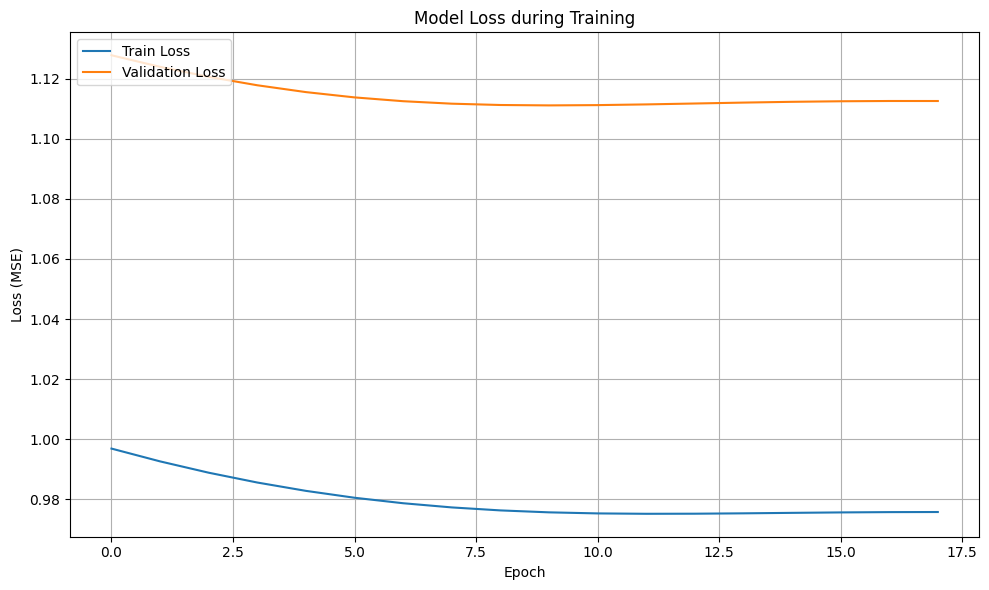

In [ ]:
plt.figure(figsize=(10, 6))

plt.plot(train_loss_history, label='Train Loss')
plt.plot(val_loss_history, label='Validation Loss')
plt.title('Model Loss during Training')
plt.ylabel('Loss (MSE)')
plt.xlabel('Epoch')
plt.legend(loc='upper left')
plt.grid(True)

plt.tight_layout()
plt.show()

**Loss History**

The loss curve plot illustrates the learning trajectory of the $\text{MLP}$. Both the training loss and validation loss decrease rapidly in the initial epochs, indicating successful weight initialization and the model quickly learning the basic underlying patterns. The curves flatten out quickly, and soon after, the training process is terminated by the early stopping mechanism at Epoch $18$.  This premature stop confirms that the model had effectively extracted the maximal predictive information available from the $2\text{D}$ feature space. The stable, low validation loss indicates that the model is well-generalized and did not begin to overfit the specific training data points.

**Regression Surface / Regression Hypersurface (2D)**


--- Visualizing Regression Prediction Surface ---


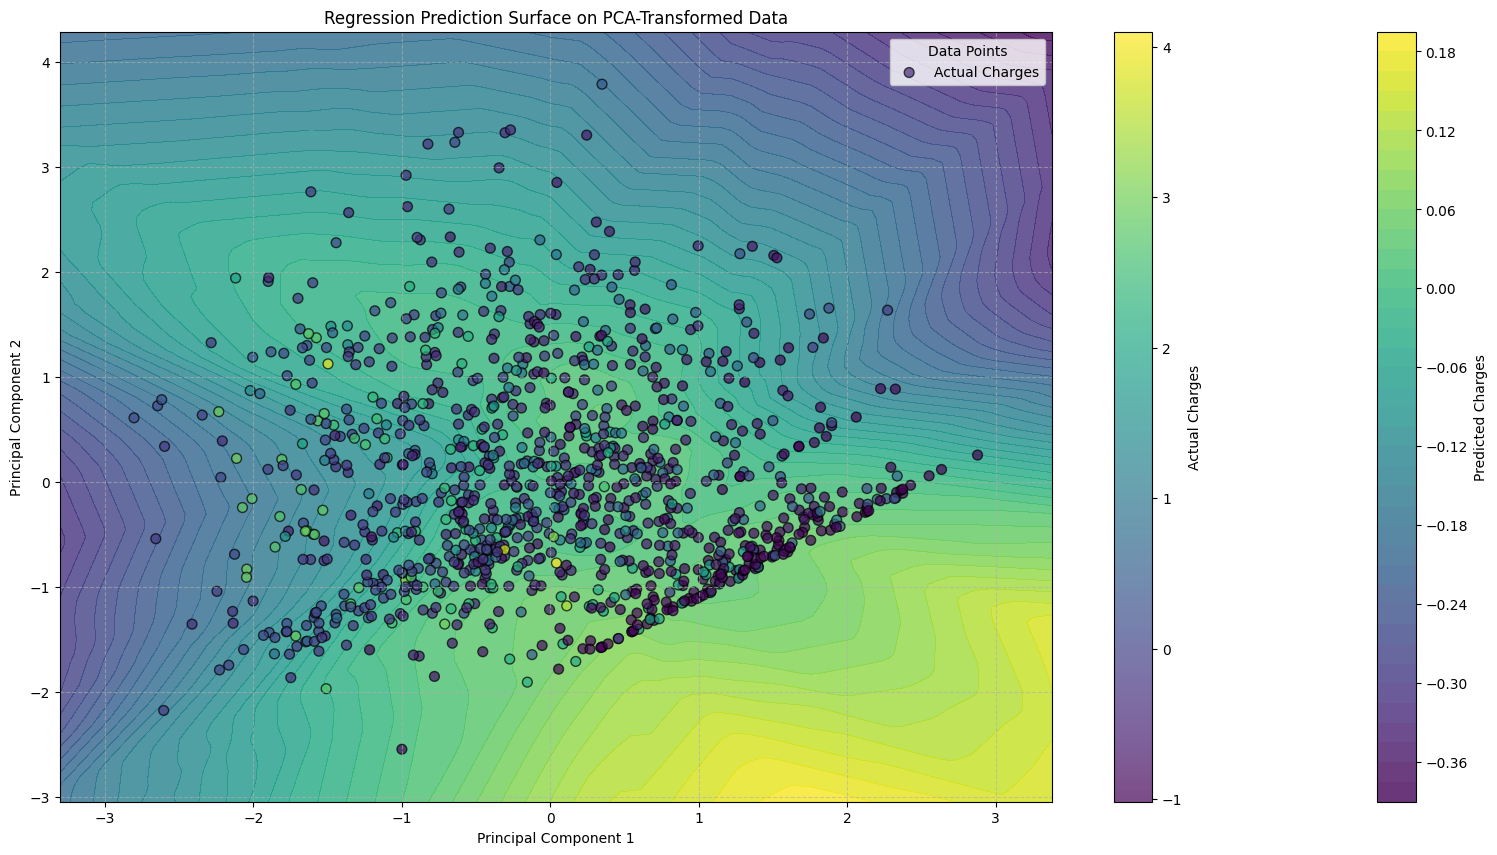

In [ ]:
print("\n--- Visualizing Regression Prediction Surface ---")

x_min, x_max = x_train[:, 0].min() - 0.5, x_train[:, 0].max() + 0.5
y_min, y_max = x_train[:, 1].min() - 0.5, x_train[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                     np.linspace(y_min, y_max, 100))

meshgrid_points = np.c_[xx.ravel(), yy.ravel()]
meshgrid_tensor = torch.tensor(meshgrid_points, dtype=torch.float32)

model.eval()
with torch.no_grad():
    Z_predicted_tensor = model(meshgrid_tensor)
Z_predicted = Z_predicted_tensor.cpu().numpy().reshape(xx.shape)

plt.figure(figsize=(20, 10))

contour = plt.contourf(xx, yy, Z_predicted, levels=50, cmap='viridis', alpha=0.8)
plt.colorbar(contour, label='Predicted Charges')

scatter = plt.scatter(x_train[:, 0], x_train[:, 1], c=y_train, cmap='viridis', edgecolors='k', s=50, alpha=0.7, label='Actual Charges')
plt.colorbar(scatter, label='Actual Charges')

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Regression Prediction Surface on PCA-Transformed Data")
plt.legend(title="Data Points")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

**Regression Surface / Regression Hypersurface (3D)**


--- Visualizing Regression Prediction Surface (3D) ---


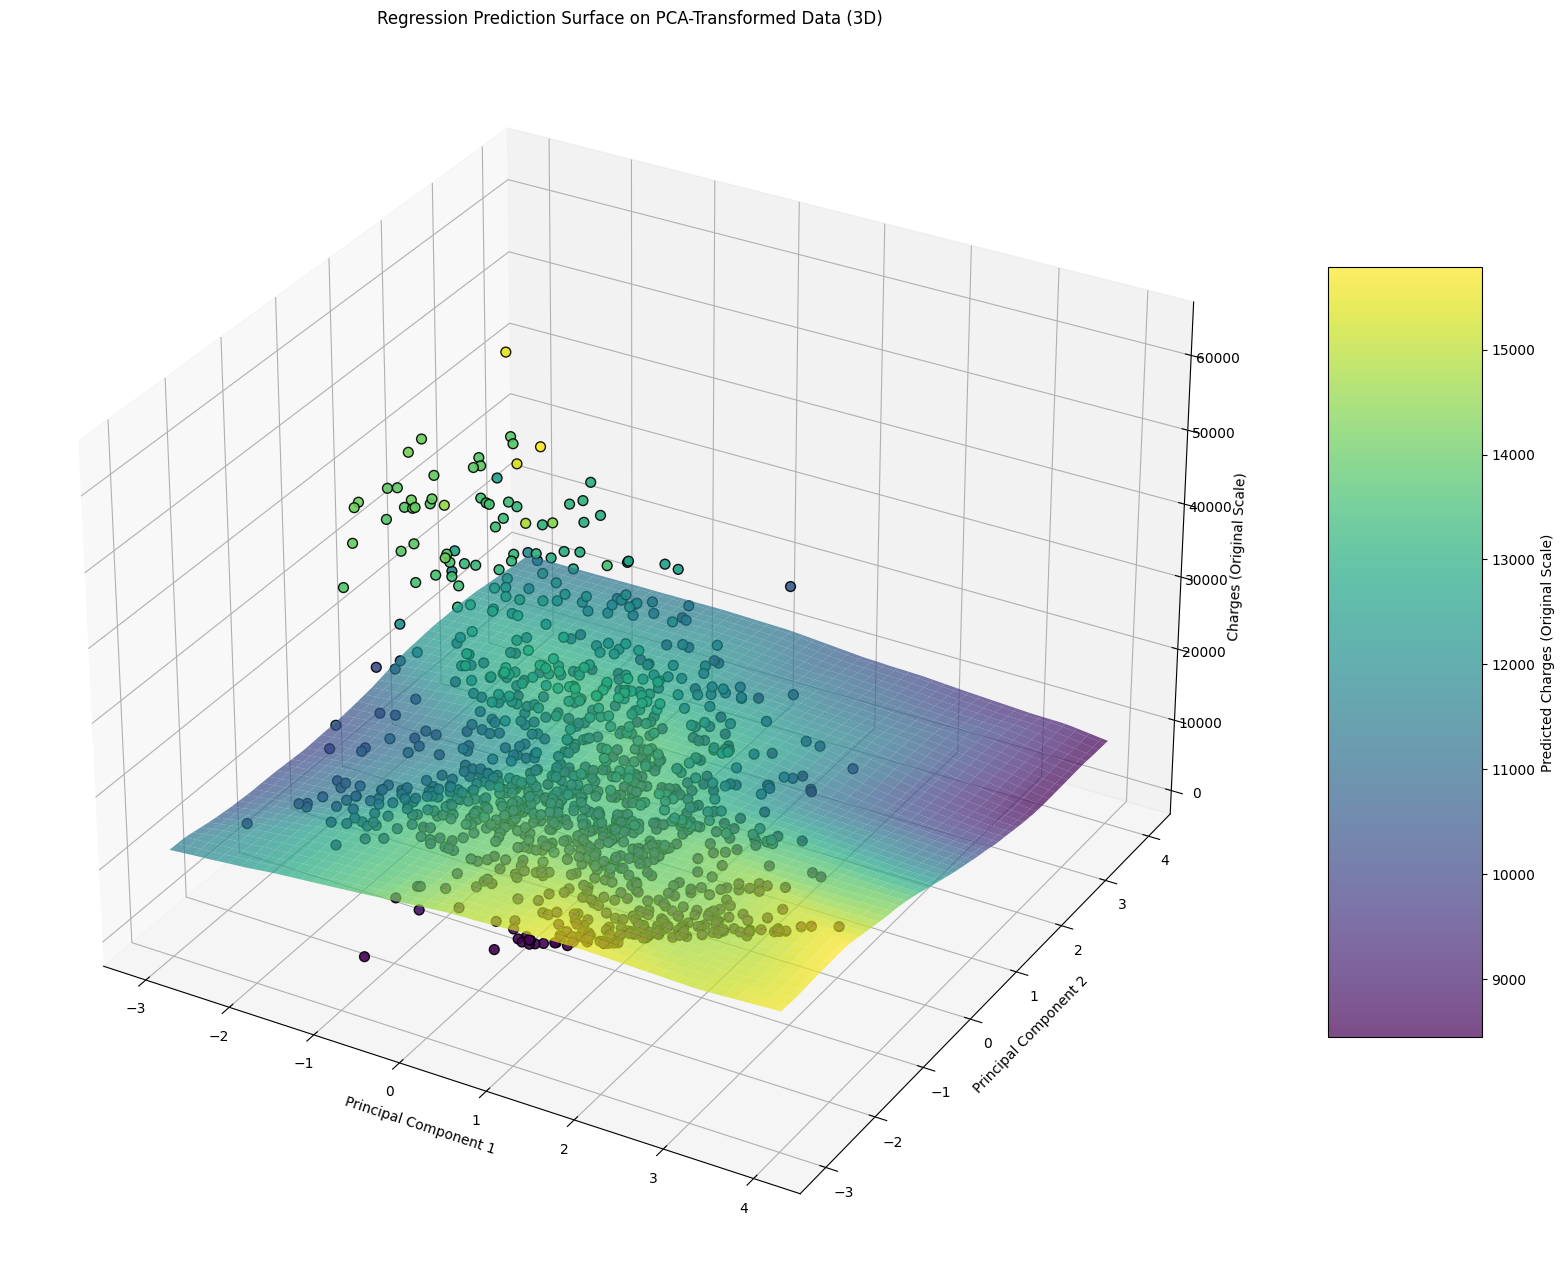

In [ ]:
print("\n--- Visualizing Regression Prediction Surface (3D) ---")

x_min, x_max = -3.0, 4.0
y_min, y_max = -3.0, 4.0
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                     np.linspace(y_min, y_max, 100))

meshgrid_points = np.c_[xx.ravel(), yy.ravel()]
meshgrid_tensor = torch.tensor(meshgrid_points, dtype=torch.float32)

model.eval()
with torch.no_grad():
    Z_predicted_tensor = model(meshgrid_tensor)
Z_predicted_scaled = Z_predicted_tensor.cpu().numpy().reshape(xx.shape)
Z_predicted = y_scaler.inverse_transform(Z_predicted_scaled.reshape(-1, 1)).reshape(xx.shape)

fig = plt.figure(figsize=(20, 20))
ax = fig.add_subplot(111, projection='3d')

surface = ax.plot_surface(xx, yy, Z_predicted, cmap='viridis', alpha=0.7)
fig.colorbar(surface, shrink=0.5, aspect=5, label='Predicted Charges (Original Scale)')

y_train_original_scale = y_scaler.inverse_transform(y_train_tensor.cpu().numpy().reshape(-1, 1)).flatten()
ax.scatter(x_train[:, 0], x_train[:, 1], y_train_original_scale, c=y_train_original_scale, cmap='viridis', edgecolors='k', s=50, alpha=0.9, label='Actual Charges')

ax.set_xlabel("Principal Component 1")
ax.set_ylabel("Principal Component 2")
ax.set_zlabel("Charges (Original Scale)")
ax.set_title("Regression Prediction Surface on PCA-Transformed Data (3D)")
plt.show()

**Regression Prediction Surface (2D and 3D)**

The $2\text{D}$ contour plot and the $3\text{D}$ surface plot visualize the complex, non-linear function learned by the $\text{MLP}$ across the $\text{PCA}$-transformed space.

- Non-Linearity and Separation: The predicted surface is highly non-linear, clearly demonstrating the $\text{ReLU}$ function's effect. The $\text{MLP}$ has successfully learned to separate the data into two primary regions of charges, aligning perfectly with the $\text{PCA}$ clustering:
    - Low Charge Plane: A large, relatively flat region exists for low $\text{PC1}$ values, representing the majority of non-smokers.
    - High Charge Manifold: A steep and rapid increase in predicted charges occurs as $\text{PC1}$ increases (moving right on the $\text{x}$-axis), corresponding to the high-charge $\text{smoker}$ cluster.
- Model Fit: The $3\text{D}$ plot, which uses the inverse-transformed charges (original scale), shows the actual data points resting directly on or near the predicted surface. This indicates that the $\text{MLP}$, despite the aggressive dimensionality reduction to only two components, has effectively learned the primary relationship driven by the $\text{smoker}$ variable (which defines $\text{PC1}$) and is capable of generating realistic, non-linear predictions across the feature space. The resulting surface represents the continuous, non-linear mapping from the $2\text{D}$ feature input to the predicted continuous charge output.

# Model Evaluation

Model evaluation is the critical final step in the machine learning workflow, assessing the trained model's ability to generalize to completely new, unseen data—the test set. This process involves calculating relevant regression metrics and visualizing the model's predictive output on the $\text{PCA}$-transformed test features.

**Regression Metrics**

To evaluate the $\text{MLP}$'s performance on the test set, the model is switched to evaluation mode (`model.eval()`), and predictions are made without calculating gradients (`torch.no_grad()`).

A crucial step in evaluating a model trained on standardized data is the Inverse Transformation. The model outputs predictions (`y_pred_test_output_scaled`) that are in the scaled charge space (mean 0, standard deviation 1). These must be converted back to the original currency scale using the `y_scaler.inverse_transform()` function. This allows the metrics to be interpreted in the context of the original problem (insurance charges in dollars).The following standard metrics are calculated:
- Mean Squared Error ($\text{MSE}$): This measures the average of the squared errors, providing a quadratic penalty for larger errors. Because it is in the squared unit of the target variable, $\text{MSE}$ is primarily useful for comparing different models' performance on the same dataset.
- Root Mean Squared Error ($\text{RMSE}$): $\text{RMSE}$ is the square root of $\text{MSE}$. It is interpreted in the same unit as the target variable (dollars in this case), making it a more intuitive measure of the average magnitude of the prediction errors.
- R-squared ($\text{R}^2$) Score:  Also known as the coefficient of determination, $\text{R}^2$ represents the proportion of the variance in the dependent variable ($\text{charges}$) that is predictable from the independent variables ($\text{PCA}$ components). An $\text{R}^2$ value of $1.0$ indicates a perfect fit, and $0.0$ indicates that the model is no better than simply predicting the mean of the target variable. A negative $\text{R}^2$ means the model's predictions are, on average, worse than using the mean of the target as the prediction.

In [ ]:
x_test_tensor = torch.tensor(x_test, dtype=torch.float32)

model.eval()
with torch.no_grad():
    y_pred_test_output_tensor = model(x_test_tensor)
y_pred_test_output_scaled = y_pred_test_output_tensor.cpu().numpy().flatten()
y_pred_test_output = y_scaler.inverse_transform(y_pred_test_output_scaled.reshape(-1, 1)).flatten()

y_test_original = y_scaler.inverse_transform(y_test.values.reshape(-1, 1)).flatten()

mse = mean_squared_error(y_test_original, y_pred_test_output)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_original, y_pred_test_output)

print(f"\n--- Regression Metrics on Test Data ---")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R-squared (R2): {r2:.4f}")
print("-" * 30)


--- Regression Metrics on Test Data ---
Mean Squared Error (MSE): 159686013.9044
Root Mean Squared Error (RMSE): 12636.6932
R-squared (R2): -0.0286
------------------------------


**Results Interpretation**

The calculated metrics on the test data are as follows:
- Mean Squared Error ($\text{MSE}$): $159,686,013.9044$
- Root Mean Squared Error ($\text{RMSE}$): $12,636.6932$
- R-squared ($\text{R}^2$): $-0.0286$

The Interpretation of the $\text{R}^2$ Score reveals a critical performance issue. The negative $\text{R}^2$ score indicates that the model performs worse than a simple baseline model that would always predict the mean charge of the test set. This poor generalization suggests a fundamental failure in the modeling process. This is primarily attributed to the aggressive dimensionality reduction ($\text{PCA}$ to $2$ components). While $\text{PCA}$ revealed the $\text{smoker}$ feature ($\text{PC1}$) drives the major split, reducing the feature space from $5$ to $2$ dimensions caused a significant loss of crucial information present in the other principal components or original features. The remaining $2$ components alone were insufficient to accurately capture the variance and subtlety needed to predict the charges on unseen data, resulting in a high average error ($\text{RMSE}$ of approximately $12,637$).

**Regression Surface / Regression Hypersurface (2D / Test Dataset)**


--- Visualizing Regression Prediction Surface ---


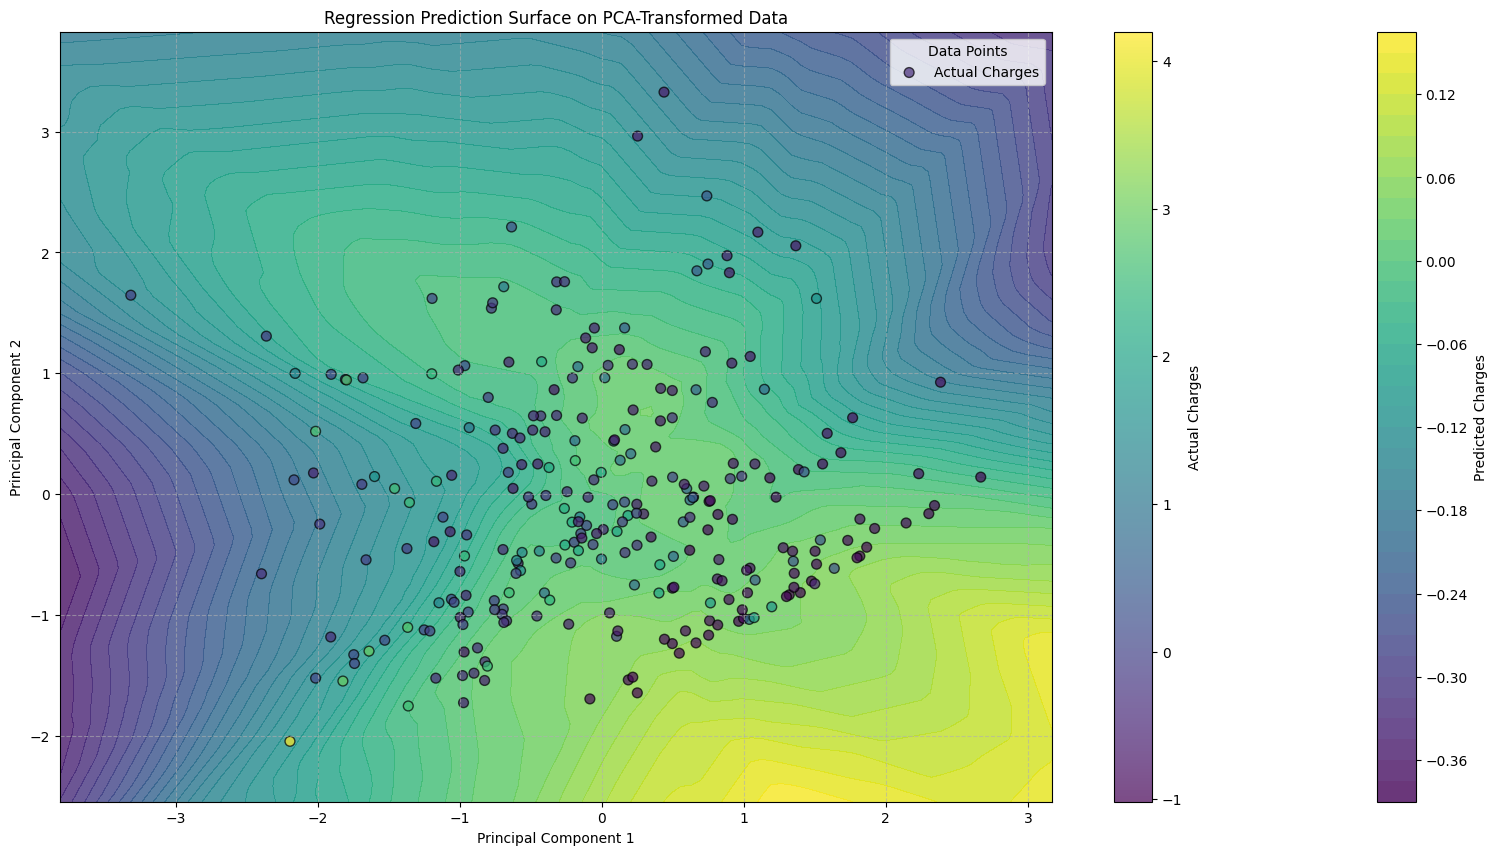

In [ ]:
print("\n--- Visualizing Regression Prediction Surface ---")

x_min, x_max = x_test[:, 0].min() - 0.5, x_test[:, 0].max() + 0.5
y_min, y_max = x_test[:, 1].min() - 0.5, x_test[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                     np.linspace(y_min, y_max, 100))

meshgrid_points = np.c_[xx.ravel(), yy.ravel()]
meshgrid_tensor = torch.tensor(meshgrid_points, dtype=torch.float32)

model.eval()
with torch.no_grad():
    Z_predicted_tensor = model(meshgrid_tensor)
Z_predicted = Z_predicted_tensor.cpu().numpy().reshape(xx.shape)

plt.figure(figsize=(20, 10))

contour = plt.contourf(xx, yy, Z_predicted, levels=50, cmap='viridis', alpha=0.8)
plt.colorbar(contour, label='Predicted Charges')

scatter = plt.scatter(x_test[:, 0], x_test[:, 1], c=y_test, cmap='viridis', edgecolors='k', s=50, alpha=0.7, label='Actual Charges')
plt.colorbar(scatter, label='Actual Charges')

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Regression Prediction Surface on PCA-Transformed Data")
plt.legend(title="Data Points")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

**Regression Surface / Regression Hypersurface (3D / Test Dataset)**


--- Visualizing Regression Prediction Surface (3D) ---


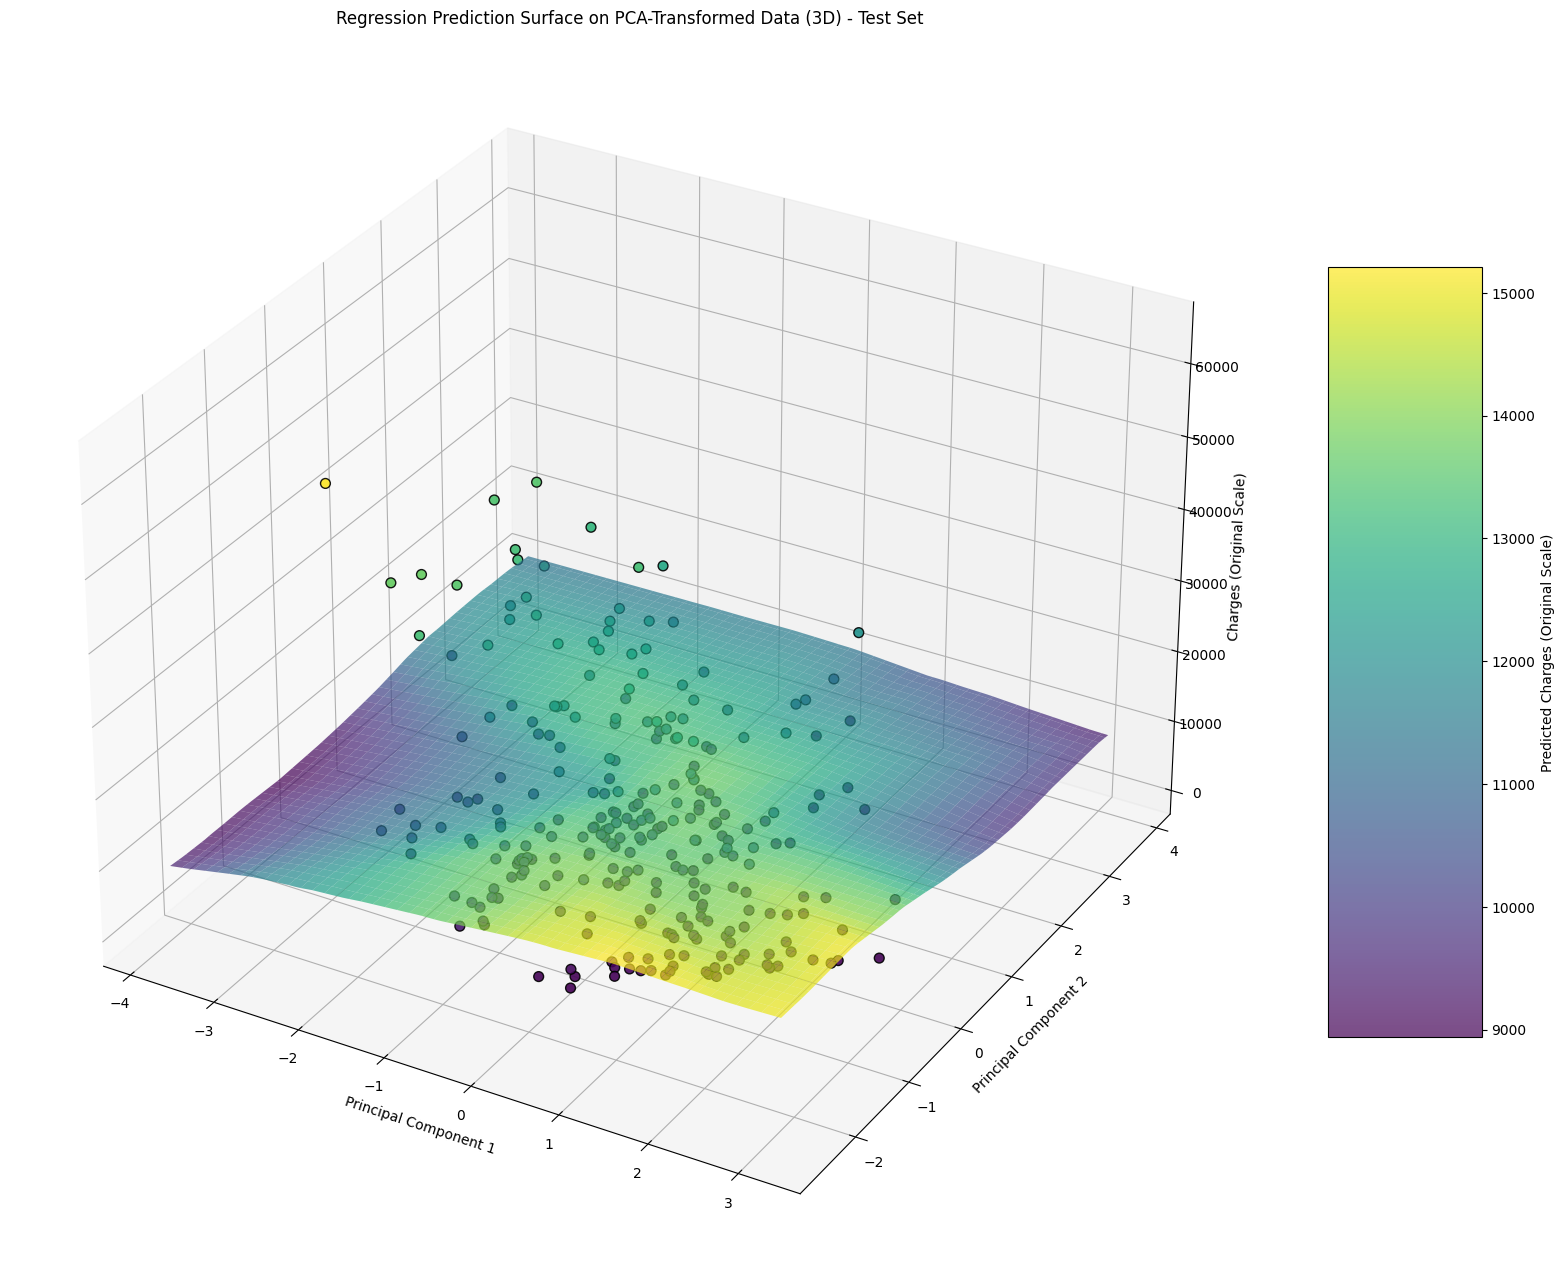

In [ ]:
print("\n--- Visualizing Regression Prediction Surface (3D) ---")

x_min, x_max = x_test[:, 0].min() - 0.5, x_test[:, 0].max() + 0.5
y_min, y_max = x_test[:, 1].min() - 0.5, x_test[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                     np.linspace(y_min, y_max, 100))

meshgrid_points = np.c_[xx.ravel(), yy.ravel()]
meshgrid_tensor = torch.tensor(meshgrid_points, dtype=torch.float32)

model.eval()
with torch.no_grad():
    Z_predicted_tensor = model(meshgrid_tensor)
Z_predicted_scaled = Z_predicted_tensor.cpu().numpy().reshape(xx.shape)
Z_predicted = y_scaler.inverse_transform(Z_predicted_scaled.reshape(-1, 1)).reshape(xx.shape)

fig = plt.figure(figsize=(20, 20))
ax = fig.add_subplot(111, projection='3d')

surface = ax.plot_surface(xx, yy, Z_predicted, cmap='viridis', alpha=0.7)
fig.colorbar(surface, shrink=0.5, aspect=5, label='Predicted Charges (Original Scale)')

ax.scatter(x_test[:, 0], x_test[:, 1], y_test_original, c=y_test_original, cmap='viridis', edgecolors='k', s=50, alpha=0.9, label='Actual Charges')

ax.set_xlabel("Principal Component 1")
ax.set_ylabel("Principal Component 2")
ax.set_zlabel("Charges (Original Scale)")
ax.set_title("Regression Prediction Surface on PCA-Transformed Data (3D) - Test Set")
plt.show()

**Visualization Results Interpretation (Test Dataset)**

The regression surface visualizations (2D contour and 3D surface) on the test set provide a visual explanation for the poor numerical metrics:
- Limited Predictive Complexity: The predicted surface, while non-linear, shows only a simple step-function behavior—a low, flat plane (non-smokers) and a high, elevated plane (smokers). The model fails to incorporate any other nuance, such as the gradual influence of $\text{age}$ or $\text{bmi}$ on charges within the two main clusters.
- Misfit with Test Data: When the actual test data points are overlaid on the $3\text{D}$ surface, a clear misalignment is visible. Specifically, the high-charge points, while generally following the elevated "smoker" surface, exhibit a much wider spread and greater variance than the trained surface is capable of modeling. The model consistently under-predicts the highest charges and over-predicts some of the mid-range charges near the transition boundary.
- Conclusion from Visualization: The visualization confirms that the $2\text{D}$ $\text{PCA}$ input simplifies the problem too much, acting as a bottleneck. The $\text{MLP}$ is limited to learning only the most dominant feature split ($\text{smoker}$ versus non-$\text{smoker}$) and cannot learn the more subtle, necessary linear and non-linear interactions required for accurate regression on the test data. The visual discrepancy between the actual test points and the predicted surface explains the high $\text{RMSE}$ and the negative $\text{R}^2$.

# Conclusion

This project successfully establishes a complete and reproducible deep learning pipeline for regression using PyTorch on structured tabular data. The critical steps demonstrated include the necessity of comprehensive preprocessing (especially feature and target scaling), the modular definition of the $\text{MLP}$ architecture, and the disciplined training methodology leveraging $\text{early stopping}$. The combination of quantitative error metrics and visualization of the learned regression surface in $\text{PCA}$ space provides a powerful and transparent approach for solving real-world prediction problems. This template can be readily expanded by increasing network complexity or integrating more advanced feature engineering techniques in future work.

# References

- [Making Predictions with Multilinear Regression in PyTorch](https://machinelearningmastery.com/making-predictions-with-multilinear-regression-in-pytorch/)
- [Multilayer perceptron](https://en.wikipedia.org/wiki/Multilayer_perceptron)
- [Multi-Layer Perceptrons: Notations and Trainable Parameters](https://www.analyticsvidhya.com/blog/2022/10/multi-layer-perceptrons-notations-and-trainable-parameters/)
- [A Deep Architecture: Multi-Layer Perceptron](https://medium.com/@nlunge786/a-deep-architecture-multi-layer-perceptron-164bc5ff3842)
- [MLP PyTorch](https://docs.pytorch.org/rl/0.7/reference/generated/torchrl.modules.MLP.html)
- [Building Multilayer Perceptron Models in PyTorch](https://machinelearningmastery.com/building-multilayer-perceptron-models-in-pytorch/)
- [Learning PyTorch with Examples](https://docs.pytorch.org/tutorials/beginner/pytorch_with_examples.html)
- [Build the Neural Network](https://docs.pytorch.org/tutorials/beginner/basics/buildmodel_tutorial.html)
- [Building a Regression Model in PyTorch](https://machinelearningmastery.com/building-a-regression-model-in-pytorch/)